# 01 — Exploratory Data Analysis
### Lending Club Accepted Loans — Credit Risk (Default Prediction)

**Data source:** https://www.kaggle.com/datasets/wordsforthewise/lending-club/data
(`accepted_2007_to_2018Q4.csv` — ~2.26M rows, 151 columns)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid')

RAW_PATH = 'accepted_2007_to_2018Q4.csv'

## 1. Loading the data

The raw file is large (2.26M rows × 151 columns, ~1.6GB). For interactive EDA you don't
need all of it in memory at once — reading a random sample is both faster to iterate on
and, done properly, statistically fine for exploring distributions. We still eyeball the
full-file `shape` first via a cheap row count, then sample.

In [2]:
def detect_working_encoding(path, candidates=("utf-8", "cp1252", "latin-1")):
    for enc in candidates:
        try:
            with open(path, encoding=enc) as f:
                for _ in f:
                    pass
            return enc
        except UnicodeDecodeError:
            continue
    raise RuntimeError(f"None of {candidates} could decode {path}")

ENCODING = detect_working_encoding(RAW_PATH)
print(f"Using encoding: {ENCODING}")

Using encoding: utf-8


In [ ]:
# row/column count without loading the full file into memory
with open(RAW_PATH, encoding=ENCODING) as f:
    n_lines = sum(1 for _ in f)
print(f"Approx rows (incl. header): {n_lines:,}")

header = pd.read_csv(RAW_PATH, nrows=0)
print(f"Columns: {header.shape[1]}")

Approx rows (incl. header): 2,260,702
Columns: 151


In [4]:
# For EDA, a representative sample is enough. Reading a fixed fraction via chunking
# keeps memory bounded regardless of how large the source file is.
SAMPLE_FRAC = 0.15
chunks = []
for chunk in pd.read_csv(RAW_PATH, chunksize=200_000, low_memory=False):
    chunks.append(chunk.sample(frac=SAMPLE_FRAC, random_state=42))
df = pd.concat(chunks, ignore_index=True)
del chunks

print(df.shape)
df.head(3)

(339105, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,61469470,NaN,14000.0,14000.0,14000.0,60 months,15.61,337.56,D,D1,regional account executive,< 1 year,RENT,95000.0,Source Verified,Oct-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,956xx,CA,7.38,1.0,Aug-2003,660.0,664.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,63919847,NaN,10000.0,10000.0,10000.0,36 months,9.99,322.63,B,B3,Sales Manager,4 years,RENT,110000.0,Source Verified,Nov-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,credit_card,Credit card refinancing,060xx,CT,10.24,1.0,Jul-1989,660.0,664.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,59300577,NaN,5000.0,5000.0,5000.0,36 months,12.69,167.73,C,C2,physicsal therapy assistant,1 year,OWN,50000.0,Verified,Sep-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,34.74,0.0,Aug-1999,685.0,689.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Defining "default" and looking at the raw target

`loan_status` is the raw outcome field, but it isn't a clean binary label — it mixes
loans that are *finished* (Fully Paid / Charged Off / Default) with loans that are
*still open* (Current, In Grace Period, Late). An open loan hasn't revealed its outcome
yet, so including it as a "good" (non-default) case would be a labeling error, not just
noise — a loan that's currently on-time could still default next month.

In [5]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             161584
Current                                                131926
Charged Off                                             39970
Late (31-120 days)                                       3241
In Grace Period                                          1307
Late (16-30 days)                                         651
Does not meet the credit policy. Status:Fully Paid        298
Does not meet the credit policy. Status:Charged Off       118
Default                                                     8
Name: count, dtype: int64

In [6]:
completed_statuses = [
    'Fully Paid', 'Charged Off', 'Default',
    'Late (31-120 days)', 'Late (16-30 days)',
]
# 'Does not meet the credit policy...' statuses are legacy loans scored under an
# old, discontinued policy — they're a different population and typically excluded.

df_completed = df[df['loan_status'].isin(completed_statuses)].copy()
print(f"Completed loans: {len(df_completed):,} of {len(df):,} "
      f"({len(df_completed)/len(df):.1%})")

bad_map = {
    'Fully Paid': 0, 'Charged Off': 1, 'Default': 1,
    'Late (31-120 days)': 1, 'Late (16-30 days)': 1,
}
df_completed['bad_flag'] = df_completed['loan_status'].map(bad_map)
df_completed['bad_flag'].value_counts(normalize=True)

Completed loans: 205,454 of 339,105 (60.6%)


bad_flag
0    0.786473
1    0.213527
Name: proportion, dtype: float64

## 3. Class imbalance

A ~21% bad rate is **mild-to-moderate** imbalance. 

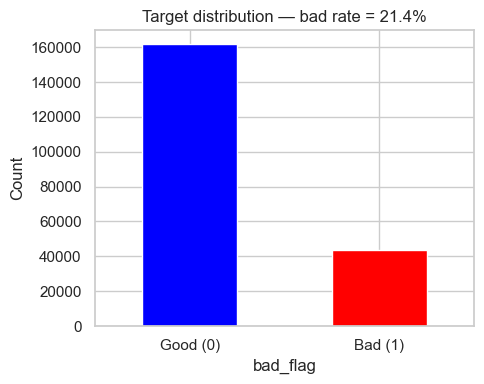

In [7]:
fig, ax = plt.subplots(figsize=(5,4))
df_completed['bad_flag'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=['blue','red']
)
ax.set_xticklabels(['Good (0)', 'Bad (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title(f"Target distribution — bad rate = {df_completed['bad_flag'].mean():.1%}")
plt.tight_layout()
plt.show()

## 4. Missingness — how much, and does it look *informative*?

Two very different situations hide behind "this column has missing values":

1. **Structurally missing** — the field genuinely doesn't apply (e.g. joint-application
   fields for an individual loan, hardship fields for a loan that never had a hardship
   plan). Here, missing *is* information — "no hardship plan" — and should often become
   a `0` / indicator rather than an imputed guess.
2. **Randomly / operationally missing** — a bureau field that just didn't get populated
   for some applications. These usually warrant median/mode imputation, ideally with a
   missingness indicator so the model can still use the fact that it was missing.

Confusing the two is a common mistake: median-imputing a "no hardship" field manufactures
a fake "typical hardship amount" for borrowers who never had one.

104 of 152 columns have missing values



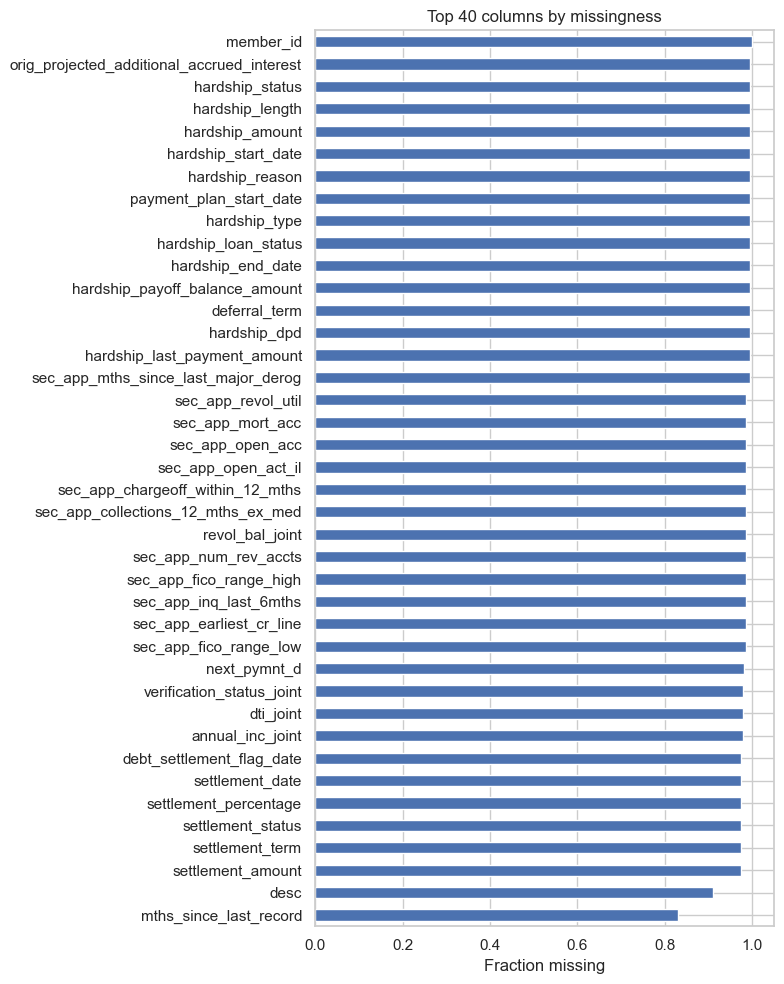

In [8]:
missing_pct = df_completed.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"{len(missing_pct)} of {df_completed.shape[1]} columns have missing values\n")

fig, ax = plt.subplots(figsize=(8,10))
missing_pct.head(40).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Fraction missing')
ax.set_title('Top 40 columns by missingness')
plt.tight_layout()
plt.show()

In [9]:
# A quick eyeball of *which kind* of missingness we're dealing with for a few columns
for col in ['mths_since_last_delinq', 'mths_since_recent_bc_dlq', 'emp_length', 'dti']:
    if col in df_completed.columns:
        print(f"{col:<28} missing={df_completed[col].isna().mean():.1%}")

mths_since_last_delinq       missing=50.3%
mths_since_recent_bc_dlq     missing=76.3%
emp_length                   missing=5.9%
dti                          missing=0.0%


`mths_since_*_delinq` fields being missing almost always means "never delinquent" —
structural, not random. `dti` and `emp_length` missingness is closer to operational
(a small fraction of applications just didn't have the field populated). We carry this
distinction into notebook 02's imputation logic.

## 5. Temporal coverage — does the population drift over time?

Lending Club's origination volume, credit mix, and macro backdrop (2007 crisis vintage
vs. 2016-2018 vintages) all shifted substantially over an 11-year window. If the bad
rate itself moves over time, a **random** train/test split will let the model "peek" at
future-period patterns during training — it isn't a fair simulation of deploying a model
trained on the past to score applications in the future. This single chart is the
justification for the out-of-time (OOT) split we build in notebook 02.

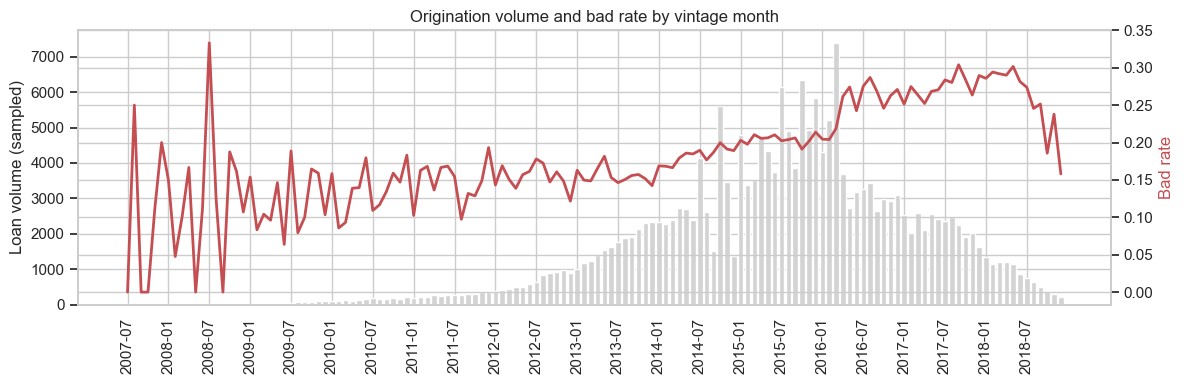

In [10]:
df_completed['issue_d'] = pd.to_datetime(df_completed['issue_d'], format='%b-%Y')

monthly = df_completed.groupby(df_completed['issue_d'].dt.to_period('M')).agg(
    n_loans=('bad_flag', 'size'),
    bad_rate=('bad_flag', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.bar(monthly.index.astype(str), monthly['n_loans'], color='lightgray', label='Volume')
ax1.set_ylabel('Loan volume (sampled)')
ax1.set_xticks(ax1.get_xticks()[::6])
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(monthly.index.astype(str), monthly['bad_rate'], color='#C44E52', linewidth=2)
ax2.set_ylabel('Bad rate', color='#C44E52')
ax1.set_title('Origination volume and bad rate by vintage month')
plt.tight_layout()
plt.show()

Two things usually jump out here: origination volume grows sharply as Lending Club
scaled up, and the bad rate for the *most recent* vintages tends to look elevated and
noisy rather than settling down. That's a trap, not a trend — and the direction is the
opposite of what intuition suggests. We already filtered to `loan_status` values that
represent a *finished* loan (`Fully Paid` / `Charged Off` / `Default` / `Late`). For a
young vintage, hardly any loans have reached natural maturity yet, so almost everything
is still sitting in `Current` and gets excluded from this view entirely. Among the small
number from a young vintage that *have* already resolved, charge-offs are
over-represented relative to payoffs: a loan can charge off early (Lending Club charges
off well before full term once a borrower stops paying), but `Fully Paid` generally
requires reaching full amortization or an early full prepayment — which takes
meaningfully longer to show up in the data. So the "completed-only" sample for a recent
vintage is quietly composition-biased toward fast defaulters. **Recent vintages look
riskier than they are, because the good loans haven't had time to finish yet.** The fix
is a seasoning/maturity cutoff: exclude loans that haven't had enough time to reach
natural maturity given their term (e.g. drop 36-month loans issued within the last ~3
years of the data's end date, and 60-month loans within the last ~5). We apply that
cutoff in notebook 02 before defining the modeling population.

## 6. Key numeric features vs. the target

For each feature we look at (a) its raw distribution and (b) how the bad rate moves
across its range — the second view is usually more useful, since it's the direction and
shape of the *relationship* that will matter for modeling (e.g. is it monotonic? is
there a threshold effect?).

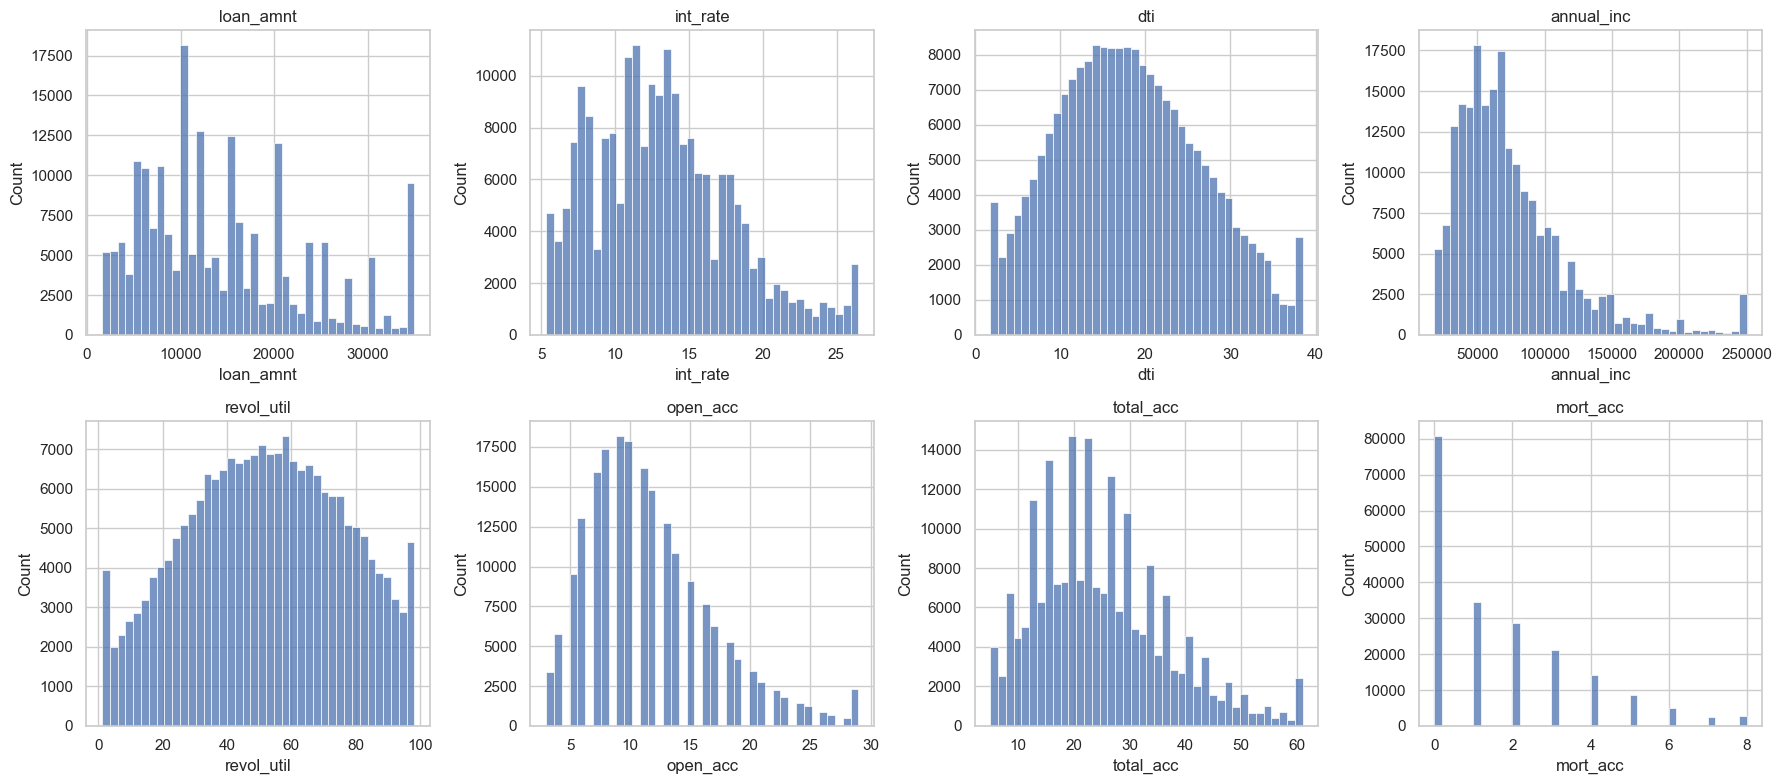

In [11]:
numeric_features = ['loan_amnt', 'int_rate', 'dti', 'annual_inc', 'revol_util',
                     'open_acc', 'total_acc', 'mort_acc']
numeric_features = [c for c in numeric_features if c in df_completed.columns]

fig, axes = plt.subplots(2, 4, figsize=(18,8))
for ax, col in zip(axes.flat, numeric_features):
    data = df_completed[col].dropna()
    # clip extreme tails just for the histogram view — raw data still used downstream
    lo, hi = data.quantile([0.01, 0.99])
    sns.histplot(data.clip(lo, hi), bins=40, ax=ax, kde=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

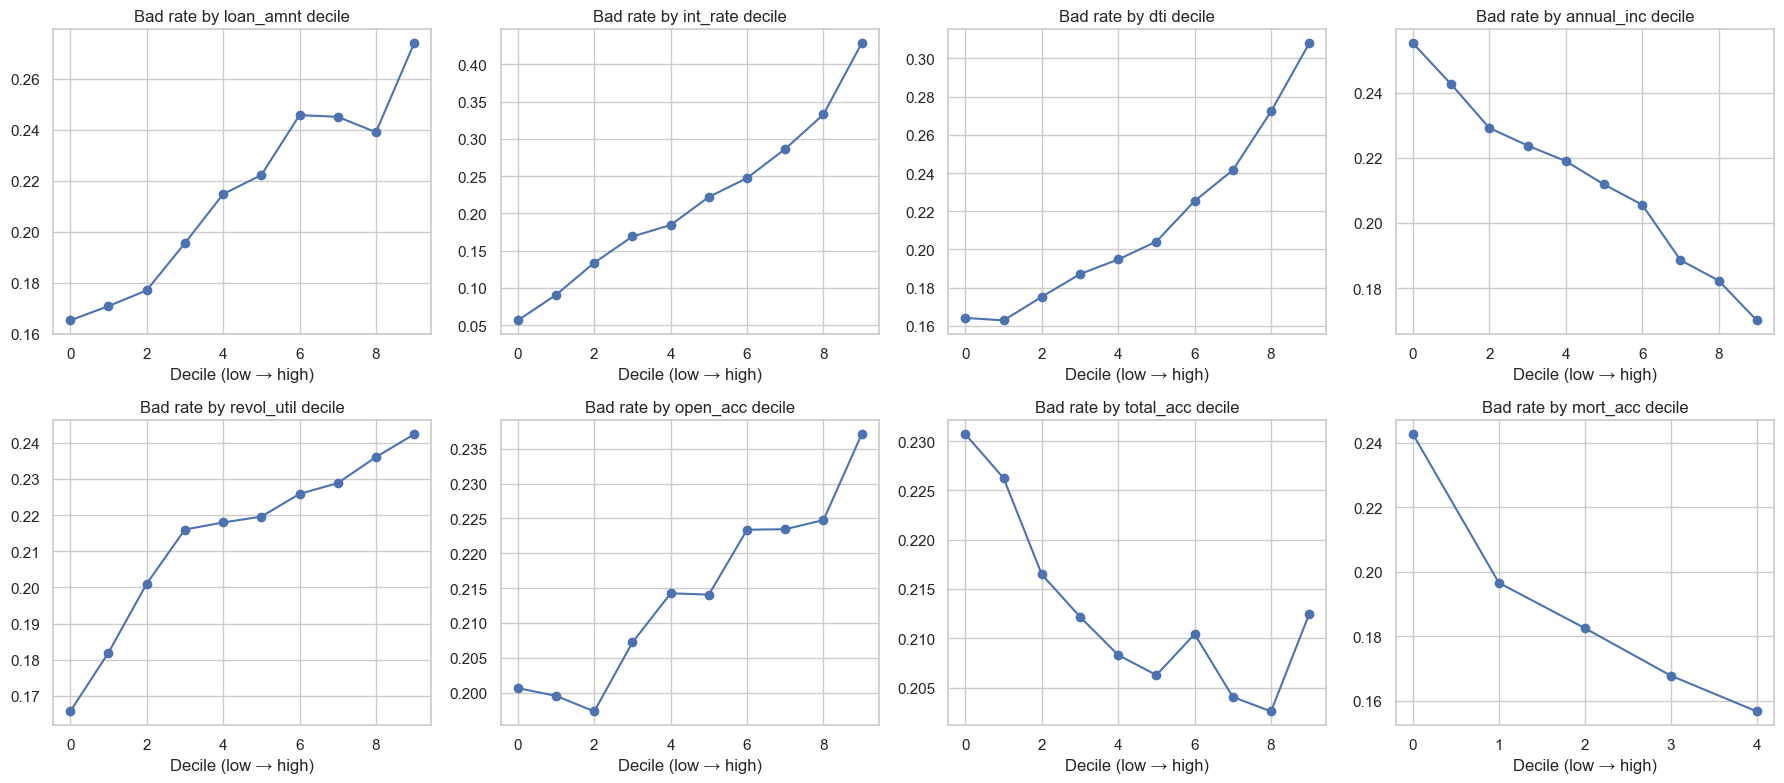

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
for ax, col in zip(axes.flat, numeric_features):
    tmp = df_completed[[col, 'bad_flag']].dropna()
    tmp['bin'] = pd.qcut(tmp[col], q=10, duplicates='drop')
    rate_by_bin = tmp.groupby('bin', observed=True)['bad_flag'].mean()
    ax.plot(range(len(rate_by_bin)), rate_by_bin.values, marker='o')
    ax.set_title(f'Bad rate by {col} decile')
    ax.set_xlabel('Decile (low → high)')
plt.tight_layout()
plt.show()

`int_rate` and `dti` should show a clean monotonic climb in bad rate — which makes
sense, since `int_rate` is itself Lending Club's own risk-based pricing, so it's
partially a proxy for a risk assessment that's already been made. That's worth flagging
now: **`int_rate`/`grade`/`sub_grade` are extremely predictive but somewhat circular** —
a model that leans heavily on them is largely reproducing Lending Club's existing risk
model rather than learning independent signal. We keep them (they're known at application
time, so they're not leakage).

## 7. Categorical features vs. the target

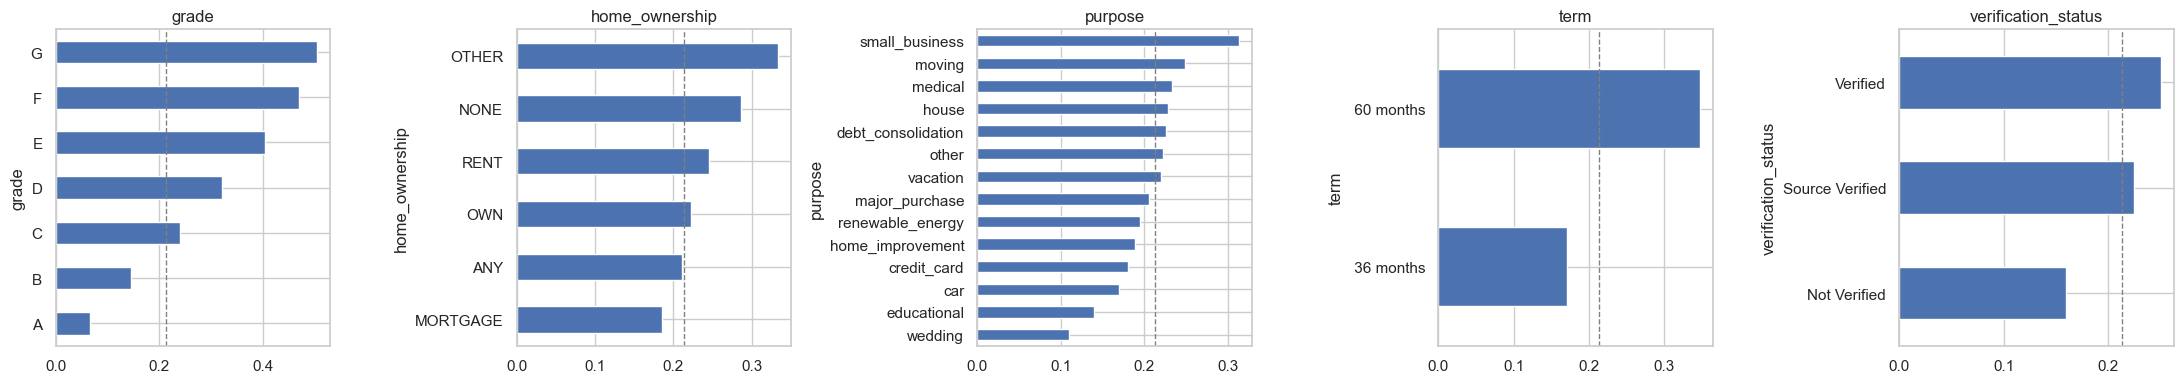

In [13]:
cat_features = ['grade', 'home_ownership', 'purpose', 'term', 'verification_status']
cat_features = [c for c in cat_features if c in df_completed.columns]

fig, axes = plt.subplots(1, len(cat_features), figsize=(22,4))
for ax, col in zip(axes, cat_features):
    rate = df_completed.groupby(col, observed=True)['bad_flag'].mean().sort_values()
    rate.plot(kind='barh', ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.axvline(df_completed['bad_flag'].mean(), color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

`grade` shows the cleanest possible monotonic relationship (A → G) — again, expected,
since it *is* Lending Club's risk grade. `purpose` and `home_ownership` show real but
much weaker separation — `small_business` and `renters` typically show elevated risk.
The dashed line is the overall bad rate; bars crossing it by a wide margin are the
categories carrying real signal.

## 8. Correlation among numeric features

Useful for two things: spotting near-duplicate features (e.g. `funded_amnt` vs.
`loan_amnt` vs. `funded_amnt_inv` are all essentially the same number) and getting an
early read on multicollinearity that could matter for the logistic regression baseline.
Tree-based models are largely indifferent to this, but it's still useful context.

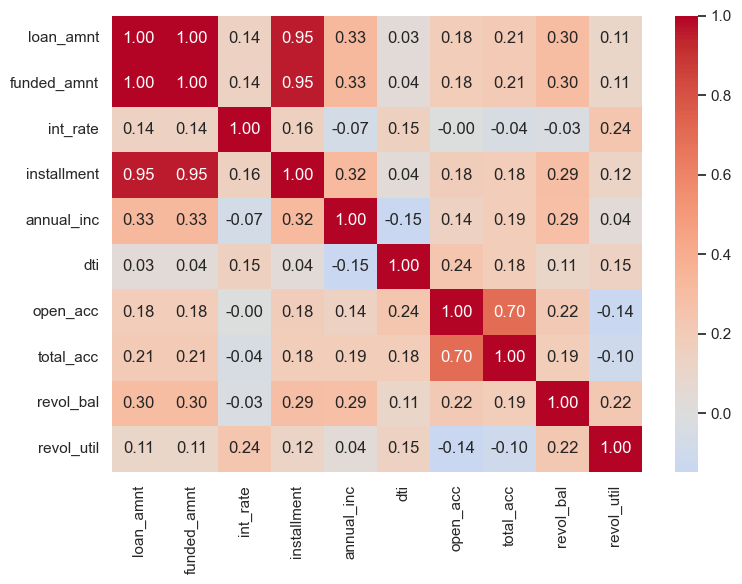

In [14]:
corr_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
             'dti', 'open_acc', 'total_acc', 'revol_bal', 'revol_util']
corr_cols = [c for c in corr_cols if c in df_completed.columns]

corr = df_completed[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.tight_layout()
plt.show()

As expected, `loan_amnt` / `funded_amnt` / `installment` move almost in lockstep — we
only need one of them (notebook 02 drops the redundant pair, keeping `loan_amnt`).

## 9. Sanity-checking outliers

A quick look for values that are wrong rather than just extreme — e.g. self-reported
`annual_inc` has a long tail that includes some values large enough to be data-entry
errors rather than real incomes, and Lending Club is known to have (rare) unverified
extreme incomes in the data.

In [15]:
print(df_completed['annual_inc'].describe(percentiles=[.5,.9,.99,.999]))
print()
print('Loans with annual_inc > $1M:', (df_completed['annual_inc'] > 1_000_000).sum())
print('Loans with dti > 100:', (df_completed['dti'] > 100).sum())

count    2.054540e+05
mean     7.607159e+04
std      6.650102e+04
min      0.000000e+00
50%      6.500000e+04
90%      1.250000e+05
99%      2.500000e+05
99.9%    5.500000e+05
max      8.400000e+06
Name: annual_inc, dtype: float64

Loans with annual_inc > $1M: 33
Loans with dti > 100: 78


These extreme values are rare enough that they won't be handled with special-case
logic — a robust scaler and (for tree models) the model's own insensitivity to outliers
handle them fine. We'll note it and move on rather than engineering around a handful of
rows.

## EDA takeaways → carried into notebook 02

1. **Target** — only completed loans (`Fully Paid`, `Charged Off`, `Default`, `Late
   (16-120 days)`) have a known outcome; everything else must be excluded, and recent
   vintages need a maturity cutoff to avoid label censoring.
2. **Imbalance** — ~20% bad rate. Moderate, not extreme — class weighting will likely
   get us most of the way; resampling is worth *testing*, not assuming.
3. **Missingness** — a real mix of "structurally absent" (→ 0 / indicator) and
   "operationally missing" (→ median). Blanket imputation would be wrong for the first
   group.
4. **Time matters** — origination volume and (apparent) bad rate both shift over the
   window. A random split overstates how well the model will generalize forward in
   time; we need an out-of-time (OOT) validation design.
5. **Redundant / circular features** — drop duplicated amount fields; keep
   `int_rate`/`grade` (they're known pre-funding, so not leakage) but understand they
   partly encode an existing risk model, not independent signal.
6. **Outliers** — present but not extreme enough to need special handling beyond
   standard scaling / tree-model robustness.